In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import glob

lpg_map_str = """
111	108	105	102	100	103	106	105	105	105	105	102
111	111	110	103	101	103	107	107	108	108	108	105
111	113	113	106	102	105	110	111	111	111	111	107
112	113	113	110	106	107	110	111	111	111	111	107
112	113	113	111	108	110	112	114	115	115	114	110
110	112	113	112	111	112	112	112	115	114	112	110
111	112	112	113	111	113	113	113	114	112	111	110
113	113	112	112	111	112	113	114	115	113	111	110
116	114	114	113	112	115	120	120	121	118	116	110
117	115	115	114	117	122	125	125	126	122	121	110
117	115	114	114	117	121	123	123	121	118	118	109
117	116	114	114	117	118	113	112	107	105	104	103
"""

lpg_map = []

for line in lpg_map_str.splitlines():
    if line:
        lpg_map.append([int(x) for x in line.split("\t")])

files = glob.glob("logs/*.txt")

df = pd.read_csv(files[-1])
df.columns=["time", "rpm", "inj", "lpg_inj", "o2_voltage", "stft1", "ltft1", "speed", "airflow"]
df = df[df["lpg_inj"] > 0]
df = df.loc[df.rpm.shift(1) != df.rpm]

rpms = [750, 1500, 2000, 2250, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]
injs = [2, 2.5, 3, 3.5, 4.5, 6, 8, 10, 12, 14, 16, 18]

#rpms = np.arange(500, 6000, 500)
#injs = np.arange(0, 25, 0.5)

ft = []
o2_voltage = []

mode = 0
ran = 0

for i_inj in range(len(injs)):
    temp_ft = []
    temp_o2_voltage = []
    for i_rpm in range(len(rpms)):
        if i_rpm <= ran:
            min_rpm = 500
        else:
            min_rpm = (rpms[i_rpm - 1 - ran] + rpms[i_rpm]) / 2 if mode else rpms[i_rpm - 1 - ran]

        if i_rpm >= len(rpms) - 1 - ran:
            max_rpm = 7000
        else:
            max_rpm = (rpms[i_rpm + 1 + ran] + rpms[i_rpm]) / 2 if mode else rpms[i_rpm + 1 + ran]
        
        if i_inj <= ran:
            min_inj = 1
        else:
            min_inj = (injs[i_inj - 1 - ran] + injs[i_inj]) / 2 if mode else injs[i_inj - 1 - ran]

        if i_inj >= len(injs) - 1 - ran:
            max_inj = 30
        else:
            max_inj = (injs[i_inj + 1] + injs[i_inj]) / 2 if mode else injs[i_inj + 1 + ran]

        df_filtered = df[(df['rpm'] >= min_rpm) & (df['rpm'] < max_rpm) & (df['inj'] >= min_inj) & (df['inj'] < max_inj)]
        ft_col = df_filtered["stft1"] + df_filtered["ltft1"]
        df_filtered = df_filtered.assign(ft=ft_col)
        temp_ft.append(round(df_filtered['ft'].mean(), 0))
        temp_o2_voltage.append(round(df_filtered['o2_voltage'].mean() * 2, 1) / 2)
    ft.append(temp_ft)
    o2_voltage.append(temp_o2_voltage)

ft_df = pd.DataFrame(ft, columns=rpms, index=injs)
o2_voltage_df = pd.DataFrame(o2_voltage, columns=rpms, index=injs)

ft_df = ft_df.apply(lambda x: round(x, 2))
o2_voltage_df = o2_voltage_df.apply(lambda x: round(x, 2))

df.ltft1.min(), df.ltft1.max()

IndexError: list index out of range

<Axes: >

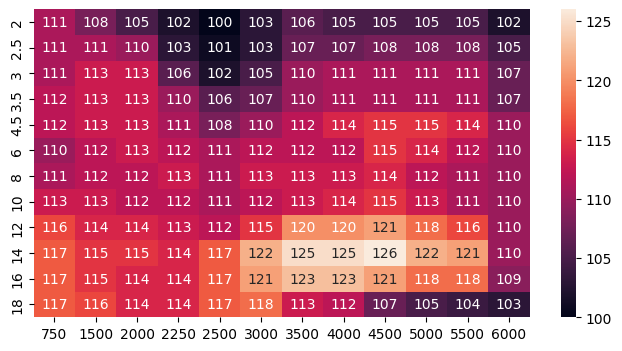

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(lpg_map, annot=True, fmt="d", xticklabels=rpms, yticklabels=injs)

<Axes: >

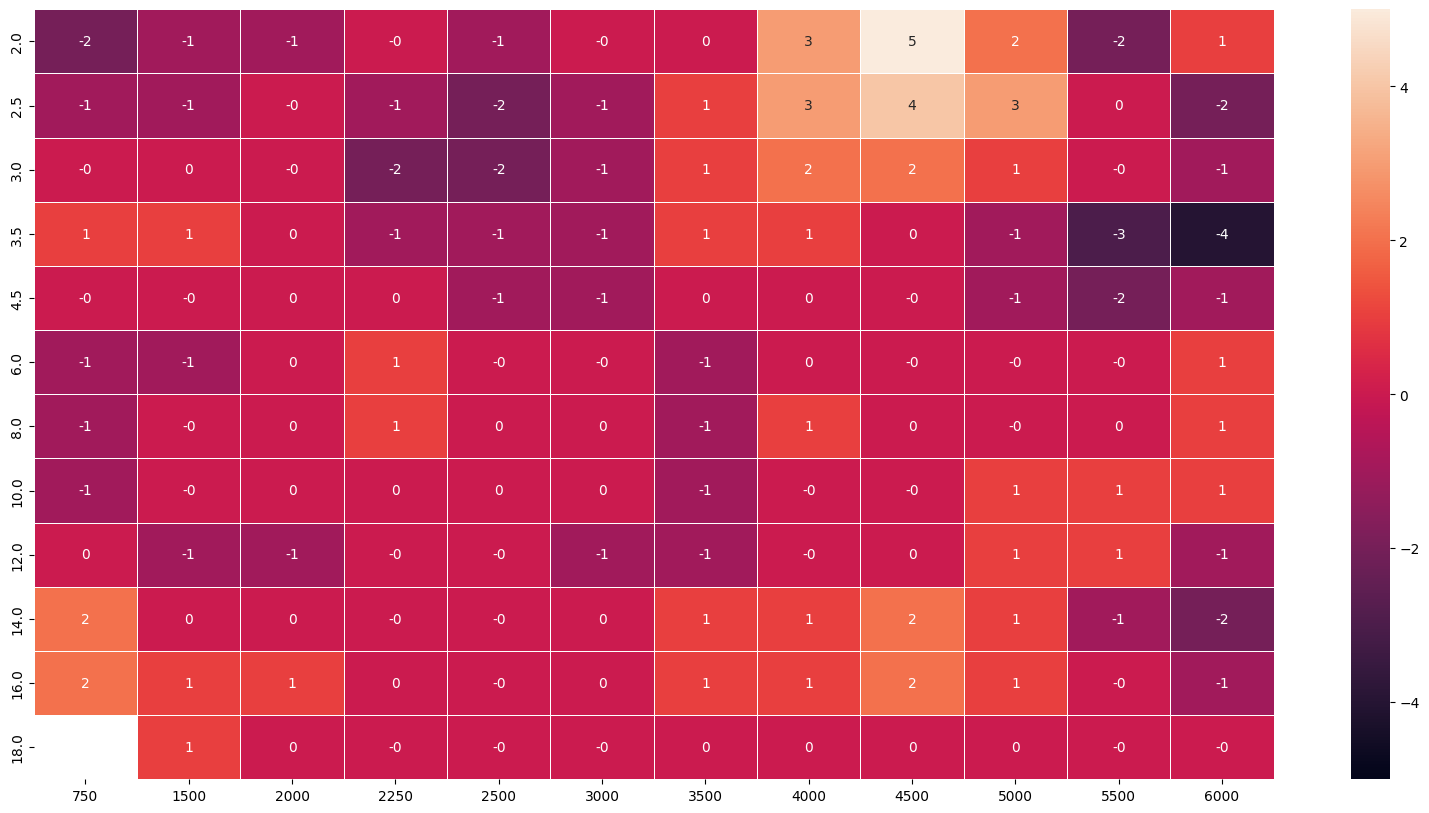

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(ft_df, annot=True, fmt=".0f", vmin=-5, vmax=5, linewidths=0.5)

<Axes: >

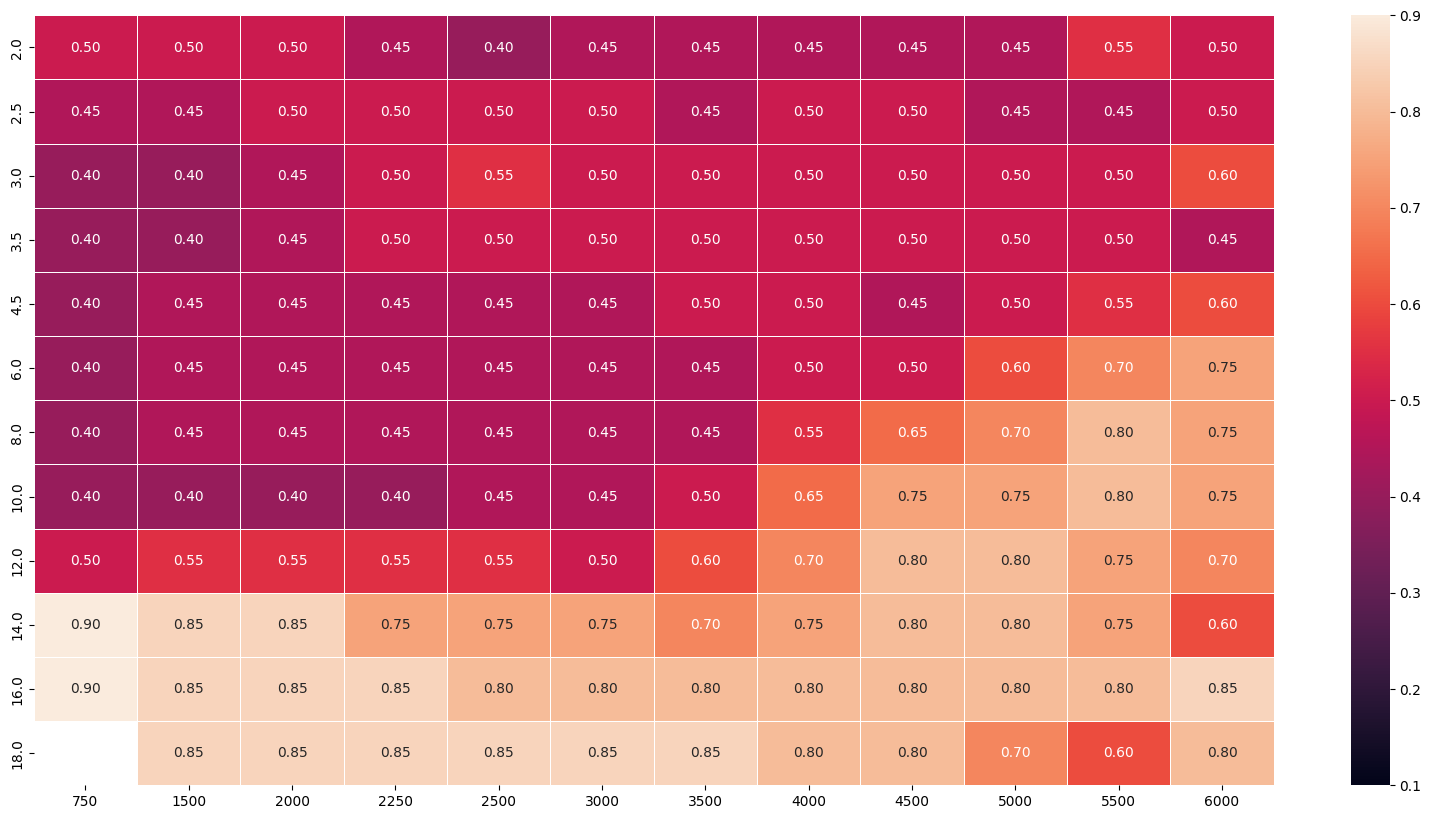

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(o2_voltage_df, annot=True, fmt=".2f", vmin=0.1, vmax=0.9, linewidths=0.5)

In [ ]:
injs2 = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 22]

injs_ft = []
injs_o2_voltage = []

for i_inj in range(len(injs2)):
    if i_inj <= 1:
        min_inj = 1
    else:
        #min_inj = (injs2[i_inj - 1] + injs2[i_inj]) / 2
        min_inj = injs2[i_inj - 1]
    if i_inj >= len(injs2) - 1:
        max_inj = 30
    else:
        #max_inj = (injs2[i_inj + 1] + injs2[i_inj]) / 2
        max_inj = injs2[i_inj + 1]
    df_filtered = df[(df['inj'] >= min_inj) & (df['inj'] < max_inj)]
    ft_col = df_filtered["stft1"] + df_filtered["ltft1"]
    df_filtered = df_filtered.assign(ft=ft_col)

    injs_ft.append(df_filtered['ft'].mean())
    injs_o2_voltage.append(df_filtered['o2_voltage'].mean())

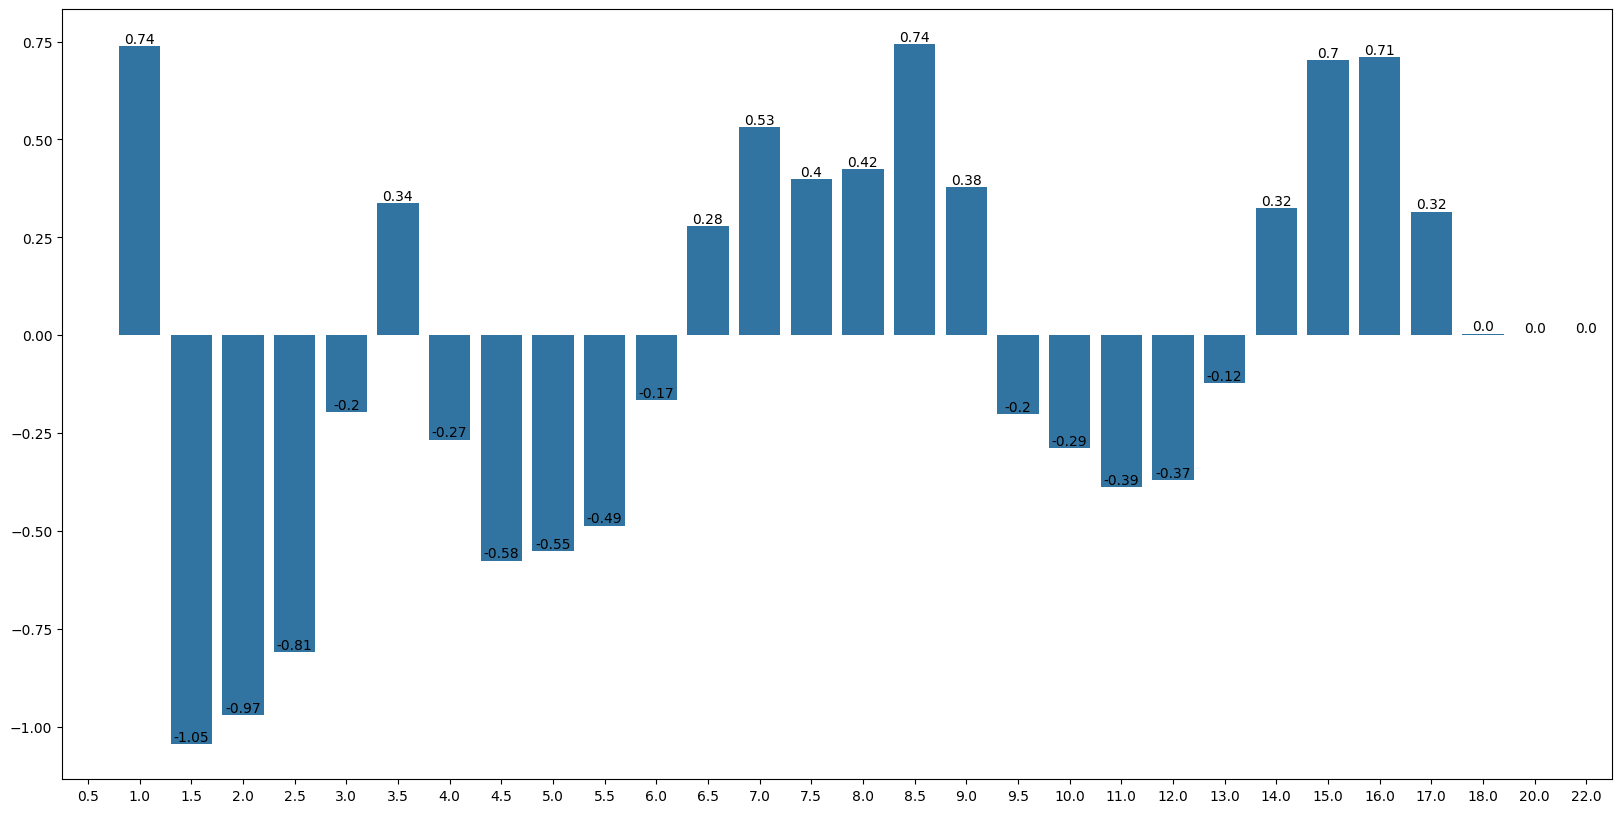

In [ ]:
#injs_ft = np.nan_to_num(injs_ft, copy=False)
plt.figure(figsize=(20, 10))
ax = sns.barplot(x=injs2, y=injs_ft)
#add values to barplot
for i in range(len(injs_ft)):
    ax.text(i, injs_ft[i], round(injs_ft[i], 2), ha='center', va='bottom')

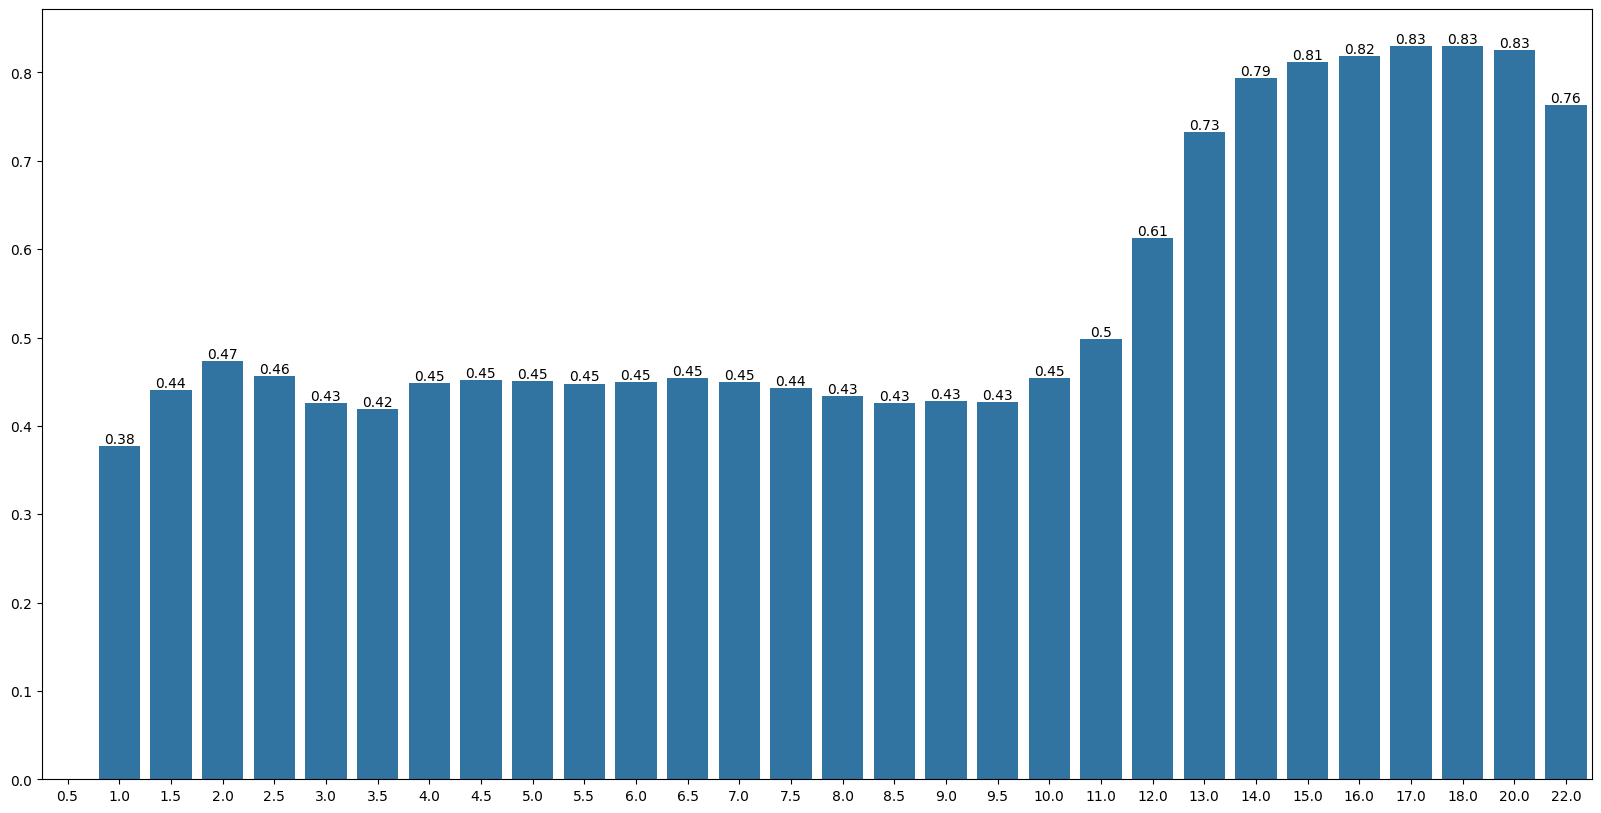

In [ ]:
#injs_o2_voltage = np.nan_to_num(injs_o2_voltage, copy=False)
plt.figure(figsize=(20, 10))
ax = sns.barplot(x=injs2, y=injs_o2_voltage)
#add values to barplot
for i in range(len(injs_o2_voltage)):
    ax.text(i, injs_o2_voltage[i], round(injs_o2_voltage[i], 2), ha='center', va='bottom')